# Chapter 1: Quantum Query Algorithms

Introduction to quantum algorithms running on a single quantum computer. Potential to solve problems that a classical computer cannot solve. Access to memory much easier than a classical computer. Quantum computers require more energy to operate.

Content:
1. The query model of computation
2. Deutsch’s Algorithm
3. The Deutsh’s-Jozsa algorithm
4. Simon’s Algorihm
5. Implementation on Qiskit

## 1. The Query model of coumputation
Abstract diagram of a conventional computer:

<div align="center">
    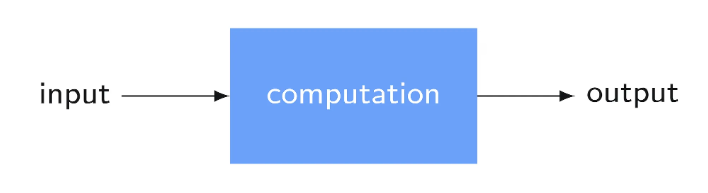
</div>

Different specific calculation models are studied, including Turing machines and Boolean circuits. 

Key point: the entire input is provided to the calculation, generally as a binary string, with no part of it masked.

In the query model, the input is available as a function, and the calculation is performed as a query. This amounts to evaluating the function with different inputs.

<div align="center">
    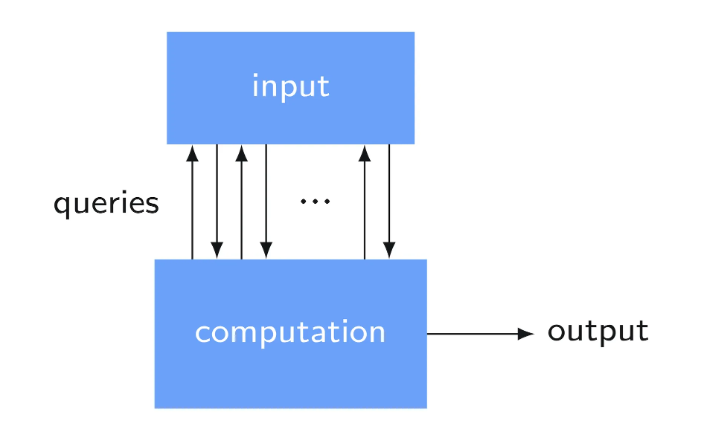
</div>

The terms Oracle and Black Box refer to mechanisms that provide input. These terms are used because an oracle answers questions without giving all known information, and a black box provides input and receives output without knowing what is happening inside.

In the lesson, the input to the problem query is represented as:

$$
f: \Sigma^n \to \Sigma^m
$$

where $n$ and $m$ are positive integers with $\Sigma = \left\{0,1 \right\}$

On some problems, there are restrictions on n and m.

Requests:

To say that a calculation makes requests is to say that it evaluates the function $f$ once with $x \in \Sigma^n$ selected, and a string $f(x)\in \Sigma^m$ is made available for the calculation. The efficiency of request algorithms is measured by counting the number of requests relative to the number of inputs required.

Example of a query algorithm:

<b>OR<b/>:

>Input: $f : \Sigma^n \to \Sigma$\
>Output: 
>- 1 if there is a string $x\in\Sigma^n$ for each $f(x) = 1$
>- 0 if there is no such string

<b>Parity<b/>:
>Input: $f: \Sigma^n \to \Sigma$\
>Output: 
>- 0 if $f(x) = 1$  for an even number of strings $x \in \Sigma^n$
>- 1 if $f(x) = 1$  for an odd number of strings $x \in \Sigma^n$

<b>Minimum<b/>:
>Input: $f: \Sigma^n \to \Sigma^m$\
>Output: The string $y\in \left\{ f(x): x\in\Sigma^n \right\}$ comes  in lexicographical order (dictionary order) of $\Sigma^m$


Sometimes query problems assume that we have a promise on the input. Inputs that do not satisfy the promise are considered unimportant.

Example: 
<b>Unique Search<b/>:
>Input: $f : \Sigma^n \to \Sigma$\
>Promise: There is exactly one string $z\in\Sigma^n$ for which $f(z) = 1$ with $f(x) = 0$ for all strings $x \neq z$\
>Output:  The string $z$

These problems are fairly natural examples of query problems. But some query problems are not of this form. They are sometimes considered complicated and highly artificial, such that it is difficult to imagine any real practical interest in solving them.

Query gate:

For certain calculation models, queries are performed as query gates. For Boolean circuits, query gates are generally calculated directly as an input function $f$.

<div align="center">
    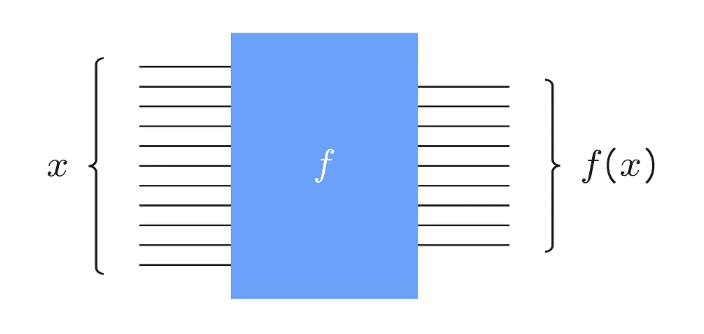
</div>

Example: this circuit calculates the parity for all $f : \Sigma \to \Sigma$, equivalent to the $XOR$ function.

<div align="center">
    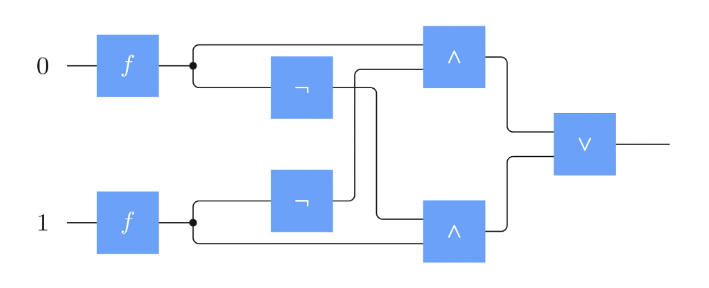
</div>

For a quantum circuit, we choose a different definition of a query gate, which performs a unitary operation.

<u>Definition</u>: 
>A query gate $U_f$ for any function $f : \Sigma^n \to \Sigma^m$ is defined as:
>$$
U_f(|y\rangle|x\rangle) = |y\oplus f(x)\rangle|x\rangle
$$
For all $x\in\Sigma^n$  and for all $y \in \Sigma^m$. $U_f$ is unitary.

Notation: 
>The string $y\oplus f(x)$ is the binary XOR operation of y and f(x). For example:
>$$
001\oplus 101 = 100
$$

A circuit diagram for $U_f$ is illustrated as follows:
<div align="center">
    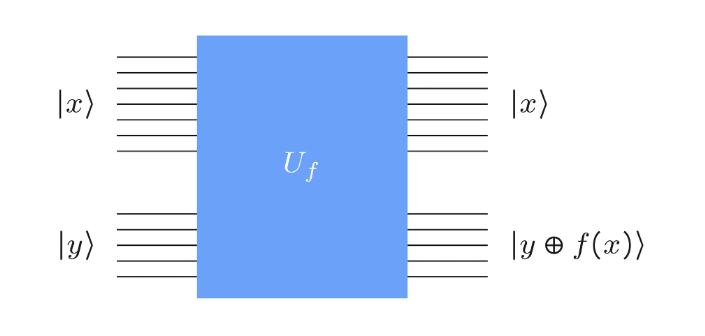
</div>

The choice of XOR is that the function is unitary regardless of the choice of f. This is a deterministic operation. This allows us to obtain a permutation matrix that is unitary. In this case, we can obtain the inverse operation.

Notation:
$$0^M = \underbrace{00...00}_\textrm{repeat M times} $$

## 2.Deutsch's Algorithm
The algorithm problem is a function parity problem of the form $f : \Sigma\to\Sigma$ (bit to bit).\
There are four functions of the form $f : \Sigma\to\Sigma$.

| a  | $f_1(a)$ | $f_2(a)$ | $f_3(a)$ | $f_4(a)$ | 
| :- |:-------:|:-------:|:-------:|:-------:|
| 0  | 0 | 0 | 1 | 1 |
| 1  | 0 | 1 | 0 | 1 |

The functions $f_1$ and $f_4$ are constant, while $f_2$ and $f_3$ are balanced.\
Deutsch's problem:
>- Input: $f : \Sigma\to\Sigma$
>- Output: O if f is constant, 1 if f is balanced.

Any classical query algorithm must have two queries to solve $f$. For a quantum query algorithm, solving such a problem is optimal because it requires only one query.

Algorithm diagram:

<div align="center">
    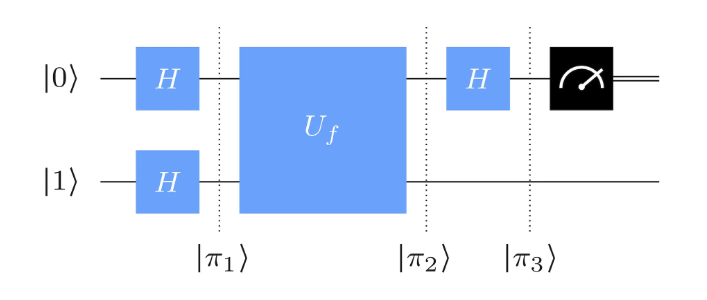
</div>

$$|\pi_1\rangle = |-\rangle|+\rangle = \frac{1}{2}(|0\rangle-|1\rangle)|0\rangle + \frac{1}{2}(|0\rangle-|1\rangle)|1\rangle $$
$$|\pi_2\rangle = \frac{1}{2}(|0\oplus f(0)\rangle-|1\oplus f(0)\rangle)|0\rangle + \frac{1}{2}(|0\oplus f(1)\rangle-|1\oplus f(1)\rangle)|1\rangle $$
$$= \frac{1}{2}(-1)^{f(0)}(|0\rangle-|1\rangle)|0\rangle + \frac{1}{2}(-1)^{f(1)}(|0\rangle-|1\rangle)|1\rangle$$
$$= |-\rangle\Biggl(\frac{(-1)^{f(0)}|0\rangle+(-1)^{f(1)}|1\rangle}{\sqrt{2}}\Biggl)$$                


Formula:
$$|0\oplus a\rangle - |1\oplus a\rangle = (-1)^a(|0\rangle-|1\rangle) $$

We observe that the relationship between $\pi_1$ and $\pi_2$ is linked to the operation of $U_f$, which puts the function $f$ in exponent. We can observe an action on the phase of each term. Using a Hadamard gate on $|0\rangle$ creates the state $|-\rangle$, which allows this phenomenon to occur. This phenomenon is called the phase kickback phenomenon.

We can observe entanglement in the last equation.
$$|\pi_2\rangle= |-\rangle\Biggl(\frac{(-1)^{f(0)}|0\rangle+(-1)^{f(1)}|1\rangle}{\sqrt{2}}\Biggl) = (-1)^{f(0)}|-\rangle\Biggl(\frac{|0>+(-1)^{f(0)\oplus f(1)}|1\rangle}{\sqrt{2}}\Biggl)
$$

$$= \begin{equation}
    \left\{ 
        \begin{array}{cc}
                (-1)^{f(0)}|->|+> & \text{if } f(0)\oplus f(1) = 0 \\ (-1)^{f(0)}|->|-> & \text{if } f(0)\oplus f(1) = 1            
    	\end{array}
    \right .
\end{equation}
$$

The last expression simplifies things so that the result can be better observed with the Hadamard gate.
$$|\pi_3\rangle = (-1)^{f(0)}|-\rangle|f(0)\oplus f(1)\rangle$$

The results after measurement give $0$ if $f$ is constant, $1$ if $f$ is balanced. The fact that the algorithm requires only one query instead of two is related to interference. The first Hadamard gate creates a superposition of states, known as constructive interference, which allows both queries to be calculated at the same time. The last Hadamard gate allows destructive interference to be associated with the wrong answer. At this point, only the correct answer is obtained.

Phase rebound phenomenon:
$$|b \oplus c\rangle = X^c|b\rangle$$

For arbitrary binary values of $b$ and $c$, if $c$ is equal to $1$, this is equivalent to applying the $NOT$ matrix ($X$ gate); if $c = 0$, this is equivalent to applying the identity operation to the set.

$$|b\oplus0\rangle = |b\rangle = I|b\rangle = X^0|b\rangle$$
$$|b\oplus1\rangle = |\neg b\rangle = X|b\rangle = X^1|b\rangle$$

Using this formula, we have:

$$
U_f(|b\rangle|a\rangle)= |b \oplus f(a)|a\rangle = (X^{f(a)}|b\rangle|)a\rangle
$$

for all bits $a,b\in\Sigma$. This formula is valid for $b = 0$, and $b = 1$, we can see the linearity: 

$$
U_f(|\psi\rangle|a\rangle) = (X^{f(a)}|\psi\rangle)|a\rangle
$$

 for any state vector $|\psi\rangle$, and 

$$
U_f(|-\rangle|a\rangle) = (X^{f(a)}|-\rangle)|a\rangle= (-1)^{f(a)}|-\rangle)|a\rangle
$$

The key to making this work is $X|-\rangle = |-\rangle|-\rangle$. In mathematical terms, this means that $|-\rangle$ is an eigenvector of $X$, which has an eigenvalue equal to $-1$. The phase rebound phenomenon will be studied in greater depth later. In simple terms, this corresponds to computational information that becomes a phase, usable in interference. \
The principle: the phase acquired by a target qubit returns to the control qubit. This allows the transfer of functional information in the phase state.

## 3.Deutsch-Jozsa's Algorithm

This algorithm is an extension of Deutsch's algorithm of the form $f : \Sigma^n \to \Sigma$ for $n \geq1$.

The task is to give an output of $0$ if $f$ is constant, and $1$ if $f$ is balanced.

The circuit is presented in the following form:
<div align="center">
    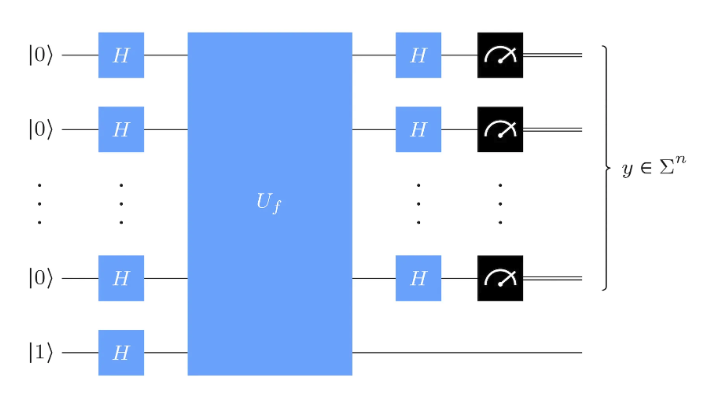
</div>

This algorithm can be used to solve many problems. For such a problem, in order for the outputs to be considered balanced or constant, the results must be output at the same frequency for $f$:

Example:
| a  | $f(x)$ |
| :- |:-------:|
| 00  | 0 |
| 01  | 0 |
| 10  | 0 |
| 11  | 1 |

The frequencies of results $0$ and $1$ are not equal in this case, so we cannot give constant or balanced results for the outputs. The number of occurrences must be identical. For the Deutsch-Jozsa algorithm, we do not need to worry about these functions. They are part of the “don't care” inputs. We have the promise that $f$ is either constant or balanced. 

Analysis of the algorithm: 

$$
H|a\rangle = \frac{1}{\sqrt{2}}|0\rangle+\frac{1}{\sqrt{2}}(-1)^a|1\rangle = \frac{1}{\sqrt{2}}\sum_{b\in\left\{ 0,1\right\}}(-1)^{ab}|b\rangle
$$

Application of the Hadamard gate for $n$ bits:

$$
H^{\otimes n}|x_{n-1}...x_1x_0\rangle \\ =(H|x_{n-1}\rangle)\otimes ... \otimes(H|x_{0}\rangle)$$
$$= (\frac{1}{\sqrt{2}}\sum_{y_{n-1}\in\Sigma}(-1)^{x_{n-1}y_{n-1}}|y_{n-1}\rangle)\otimes ... \otimes (\frac{1}{\sqrt{2}}\sum_{y_{0}\in\Sigma}(-1)^{x_{0}y_{0}}|y_{0}\rangle)  $$
$$= \frac{1}{\sqrt{2^n}}\sum_{y_{n-1}...y_0\in\Sigma^n}(-1)^{x_{n-1}y_{n-1}+...x_{0}y_{0}}|y_{n-1}...y_{0}\rangle)$$

Introduction: Binary dot product

For a binary string $x = x_{n-1}...x_0$ and for $y = y_{n-1}...y_0$, we define:
$$x\cdot y = x_{n-1}y_{n-1}\oplus ... \oplus x_{0}y_{0} \\         =                 \begin{equation}
    \left\{ 
        \begin{array}{cc}
                1 & \text{if } y = x_{n-1}y_{n-1} +... + x_{0}y_{0} \text{ is odd} \\ 0 & \text{if } y = x_{n-1}y_{n-1} +... + x_{0}y_{0} \text{ is even}       
    	\end{array}
    \right .
\end{equation}$$

The previous relationship therefore becomes:

$$
H^{\otimes n}|x\rangle \\ = \frac{1}{\sqrt{2^n}}\sum_{{y}\in\Sigma^n}(-1)^{x\cdot y}|y\rangle)
$$

This allows for a more concise version of the previous expression.

In this case, the transformations are operations in the form of:

$$
|\pi_1\rangle = |-\rangle\otimes\frac{1}{\sqrt{2^n}}\sum_{{x}\in\Sigma^n}|x\rangle \\ |\pi_2\rangle = | -\rangle\otimes\frac{1}{\sqrt{2^n}}\sum_{{x}\in\Sigma^n}(-1)^{f(x)}|x\rangle \\ |\pi_3\rangle = | -\rangle\otimes\frac{1}{2^n}\sum_{{y}\in\Sigma^n}\sum_{{x}\in\Sigma^n}(-1)^{f(x)+x\cdot y}|y\rangle
$$

$\pi_1$ corresponds to the equation upstream of the oracle, $\pi_2$  to the equation downstream of the oracle, and $\pi_3$ corresponds to the equation after the Hadamard gate before the measurement.

The probability of measuring $y=0^n$ (all bits are zero) is:

$$
P(0^n)=|\frac{1}{2^n}\sum_{x\in\Sigma^n}(-1)^{f(x)}|^2 \space= \space      \begin{equation}
    \left\{ 
        \begin{array}{cc}
                1 & \text{if f is constant}  \\ 0 & \text{if f is balanced} 
        \end{array}
    \right .
\end{equation}
$$

In this case, either the sum is zero due to the sum of positive and negative terms, or the sum is $1$.

A deterministic algorithm for Deutsch Jozas requires at least $2^{n-1}+1$ queries, compared to a single query for the quantum algorithm. A probabilistic algorithm can solve this problem using a few queries. 

1. Choose a string $x^1, ..., x^k\in\Sigma^n$ chosen randomly in a uniform manner
2. If $f(x^1) = ... = f(x^k)$, then the answer is $0$ (constant), otherwise the answer is $1$ (balanced).

If $f$ is constant, the algorithm is correct with a probability of $1$. If f is balanced, the algorithm is correct with a probability of $1-2^{-k+1}$. (e.g. for $k =11$, success rate greater than $99.9$%)

<b>The Bernstein-Vazirani problem</b>
>Input: $f : \Sigma^n \to \Sigma$\
>Promise: There is exactly one chain $s = s_{n-1}...s_0$ for which $f(x) = s\cdot x$ for all $x\in\Sigma^n$\
>Output:  The chain $s$

Similar to the Deutsch-Jozsa problem. Exercise to be developed.

## 4. Simon's Algorithm
Demonstrates an exponential advantage of quantum algorithms over classical algorithms.

<b>Algorithm</b>
>Input: $f : \Sigma^n \to \Sigma^m$\
>Promise: There is exactly one string $s \in \Sigma^n$ such that:
>$$
[f(x)=f(y)] \Longleftrightarrow [(x=y) \text{ or } (x\oplus s = y)]
$$
>for all $x,y \in \Sigma^n$\
>Output:  The string $s$

<u>Case 1</u>: $s = 0^n$

$$
[f(x)=f(y)] \Longleftrightarrow [(x=y) ]
$$

equivalent to saying that $f$ is a “one to one”

<u>Case 2</u>: $s \neq 0^n$:

In this case, $f$ must be two-to-one to satisfy the promise

$$
f(x)=f(x\oplus s)
$$

with a distinct string output for each pair. This means that each pair has a partner.

Circuit:
<div align="center">
    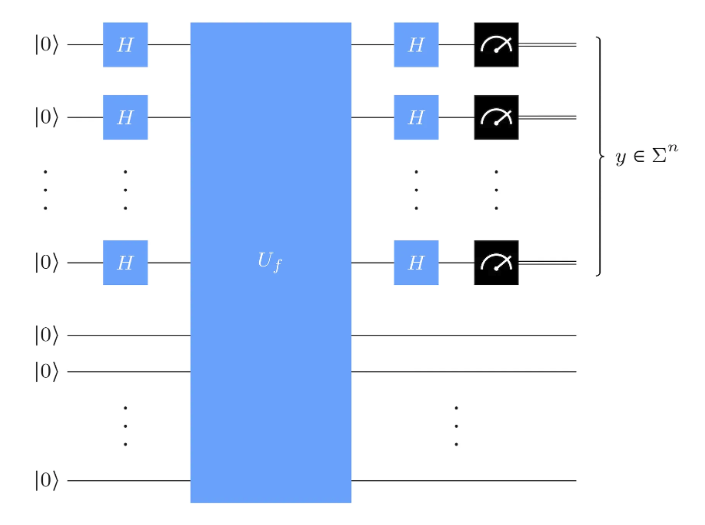
</div>

Circuit analysis: 

$$
|\pi_1\rangle = \frac{1}{\sqrt{2^n}}\sum_{{x}\in\Sigma^n}|0^m\rangle|x\rangle \\ |\pi_2\rangle = \frac{1}{\sqrt{2^n}}\sum_{{x}\in\Sigma^n}|f(x)\rangle|x\rangle \\ |\pi_3\rangle = \frac{1}{\sqrt{2^n}}\sum_{{x}\in\Sigma^n}|f(x)\rangle\oplus (\frac{1}{\sqrt{2^n}}\sum_{{y}\in\Sigma^n}(-1)^{x\cdot y}|y\rangle) \\ = \frac{1}{2^n}\sum_{{y}\in\Sigma^n}\sum_{{x}\in\Sigma^n}(-1)^{x\cdot y}|f(x)\rangle|y\rangle)
$$

where  $\pi_1$  corresponds to the equation upstream of the oracle, $\pi_2$  corresponds to the equation downstream of the oracle, and $\pi_3$ corresponds to the equation after the Hadamard gate before the measurement.

$$
p(y) = \parallel\frac{1}{2^n}\sum_{{x}\in\Sigma^n}(-1)^{x\cdot y}|f(x)\rangle \parallel^2  = \parallel\frac{1}{2^n}\sum_{{z}\in \text{range(f)}}(\sum_{{z}\in f^{-1}(z)}(-1)^{x\cdot y}|z\rangle \parallel^2  = \frac{1}{2^{2n}}\sum_{{z}\in \text{range(f)}}|\sum_{{z}\in f^{-1}(z)}(-1)^{x\cdot y} |^2  
$$

Post processing:\
<u>Case 1</u>:
>f is a one-to-one function, the probability of obtaining y is $\frac{1}{2^n}$. This is equivalent to obtaining  the appearance of each y belonging to the set with a uniform probability.

<u>Case 2</u>:
>$f$ is a two-to-one function. In this case, if $s\cdot y = 0$, the probability of obtaining the solution is $\frac{1}{2^{n-1}}$, otherwise $0$ if $s\cdot y =1$.

Gaussian elimination technique. This amounts to calculating the null space (ker) modulo 2 for the matrix m that can cover $s$. 

Classic difficulty:

Simon's algorithm solves Simon's problem with a linear number of queries, with a success probability greater than $50$%.

For a classic computer, the number of queries is exponential.


## 5. Implementation on Qiskit


In [1]:
# modules
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np


### Algorithm de Deutsch

In [2]:
def deutsch_function(case: int):
    # This function generates a quantum circuit for one of the 4 functions
    # from one bit to one bit

    if case not in [1, 2, 3, 4]:
        raise ValueError("`case` must be 1, 2, 3, or 4.")

    f = QuantumCircuit(2)
    if case in [2, 3]:
        f.cx(0, 1)
    if case in [3, 4]:
        f.x(1)
    return f

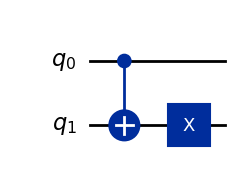

In [3]:
display(deutsch_function(3).draw(output="mpl"))

In [4]:
def compile_circuit(function: QuantumCircuit):
    # Compile a circuit for use in Deutsch's algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    qc.x(n)
    qc.h(range(n + 1))

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(range(n), range(n))

    return qc

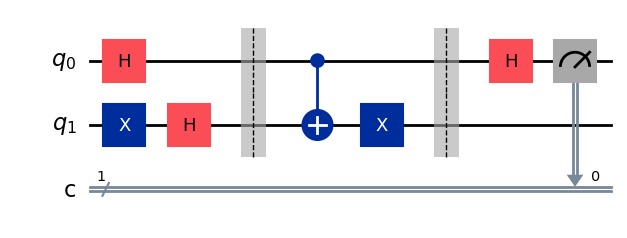

In [5]:
# la fonction de deutsch se situe entre les deux barrier
display(compile_circuit(deutsch_function(3)).draw(output="mpl"))

In [6]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if measurements[0] == "0":
        return "constant"
    return "balanced"

In [7]:
f = deutsch_function(3)
display(deutsch_algorithm(f))

'balanced'

### Deutsch - Jozsa

In [8]:
def add_cx(qc, bit_string):
    for qubit, bit in enumerate(reversed(bit_string)):
        if bit == "1":
            qc.x(qubit)
    return qc
    
def dj_query(num_qubits):
    # Create a circuit implementing for a query gate for a random function
    # satisfying the promise for the Deutsch-Jozsa problem.

    qc = QuantumCircuit(num_qubits + 1)

    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    if np.random.randint(0, 2):
        # return constant circuit with 50% chance
        return qc

    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )

    for state in on_states:
        qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    qc.barrier()

    return qc

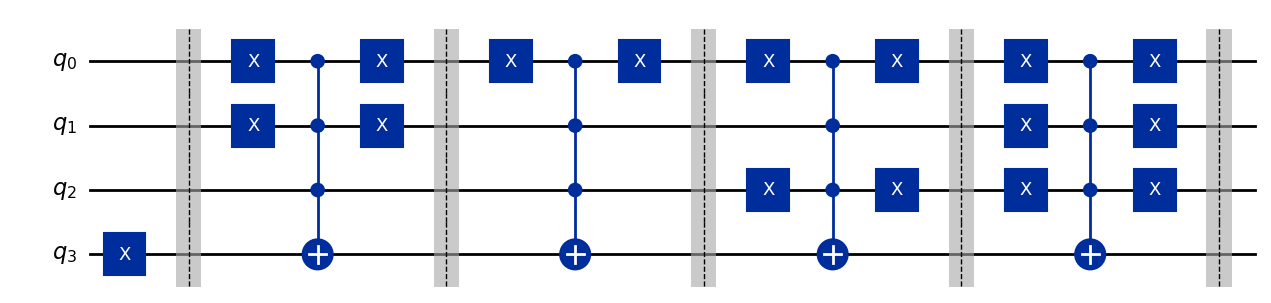

In [9]:
display(dj_query(3).draw(output="mpl"))

In [10]:
def compile_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in the Deutsch-Jozsa algorithm.

    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(range(n + 1))
    qc.compose(function, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

In [11]:
def dj_algorithm(function: QuantumCircuit):
    # Determine if a function is constant or balanced.

    qc = compile_circuit(function)

    result = AerSimulator().run(qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    return "constant"

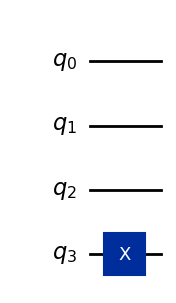

'constant'

In [12]:
f = dj_query(3)
display(f.draw("mpl"))
display(dj_algorithm(f))

### Bernstein-Vazirani problem

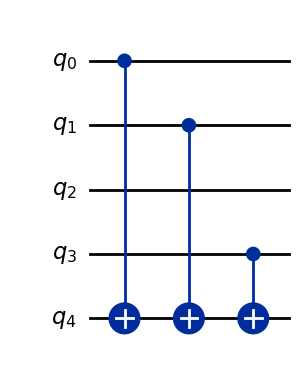

In [13]:
def bv_query(s):
    # Create a quantum circuit implementing a query gate for the
    # Bernstein-Vazirani problem.

    qc = QuantumCircuit(len(s) + 1)
    for index, bit in enumerate(reversed(s)):
        if bit == "1":
            qc.cx(index, len(s))
    return qc

display(bv_query("1011").draw(output="mpl"))

In [14]:
def bv_algorithm(function: QuantumCircuit):
    qc = compile_circuit(function)
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    return result.get_memory()[0]

display(bv_algorithm(bv_query("1101")))

'1101'

### Simon's problem

In [15]:
import galois

In [16]:
def simon_function(s: str):
    # Create a QuantumCircuit implementing a query gate for Simon problem obeying the
    # promise for the hidden string `s`

    # The quantum circuit will have 2n qubits for n being the length of s
    n = len(s)
    qc = QuantumCircuit(2 * n)

    # Define a random permutation of all n bit strings. This permutation will
    # effectively hide the string s.
    pi = np.random.permutation(2**n)

    # Now we'll define a query gate explicitly. The idea is to first define a function
    # g(x) = min{x,x ^ s}, which is a very simple function that satisfies the promise.
    # (The operation ^ is the bitwise XOR.) Then we take f to be the composition of g
    # and the random permutation pi. This gives us a random function satisfying the
    # promise for s.

    query_gate = np.zeros((4**n, 4**n))
    for x in range(2**n):
        for y in range(2**n):
            z = y ^ pi[min(x, x ^ int(s, 2))]
            query_gate[x + 2**n * z, x + 2**n * y] = 1

    # Our circuit has just this one query gate
    qc.unitary(query_gate, range(2 * n))
    return qc
    

In [17]:
def simon_measurements(problem: QuantumCircuit, k: int):
    # This is the quantum part of Simon's algorithm. Given a `QuantumCircuit` that
    # implements f, gets k measurement outcomes to be post-processed later.

    n = problem.num_qubits // 2

    qc = QuantumCircuit(2 * n, n)
    qc.h(range(n))
    qc.compose(problem, inplace=True)
    qc.h(range(n))
    qc.measure(range(n), range(n))

    result = AerSimulator().run(qc, shots=k, memory=True).result()
    return result.get_memory()

In [18]:
display(simon_measurements(simon_function("10011"),k=12))

['11101',
 '11001',
 '11101',
 '11001',
 '11110',
 '11010',
 '01011',
 '00011',
 '00011',
 '01111',
 '10010',
 '01100']

In [19]:
# utilisation du post processing, avec projection sur l'espace nul.
def simon_algorithm(problem: QuantumCircuit):
    # Given a `QuantumCircuit` that implements a query gate for Simon problem, return
    # the hidden string `s`.

    # Quantum part: run the circuit defined previously k times and gather the measurement
    # results. Replace +10 by +r for any nonnegative integer r depending on desired
    # confidence.

    measurements = simon_measurements(problem, k=problem.num_qubits // 2 + 10)

    # Classical post-processing:

    # 1. Convert measurements of form '11101' to 2D-array of integers
    matrix = np.array([list(bitstring) for bitstring in measurements]).astype(int)

    # 2. Interpret matrix as using arithmetic mod 2, and find null space
    null_space = galois.GF(2)(matrix).null_space()

    # 3. Convert back to a string
    print("Guess for hidden string s: ")
    if len(null_space) == 0:
        # No non-trivial solution; `s` is all-zeros
        return "0" * len(measurements[0])
    return "".join(np.array(null_space[0]).astype(str))

In [20]:
display(simon_algorithm(simon_function("10011")))

OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Guess for hidden string s: 


'10011'